In [31]:
from CM.TMI import TripartiteMutualInformation as tmi
import numpy as np
from tqdm import tqdm

In [32]:
eta = np.array([1/4, 1/3, 2/5, 9/20])*np.pi
r_k = 0
phi_k = 0
delta_k = 0
s_r = 0.1
s_phi = 0
m1_r = 0.1
m1_phi = 0
NL = np.arange(41, -1, -1)

I3 = np.zeros((len(eta), len(NL)))
I2_SM12 = np.zeros((len(eta), len(NL)))


for j in tqdm(range(len(NL))):
    for i in range(len(eta)):

        a = tmi(Ns=1, Nm=2, NL=NL[j], 
                eta=eta[i], r_k=r_k, phi_k=phi_k, 
                delta_k=delta_k,
                shots=1000000,
                init_state='vac',
                s_r=s_r, s_phi=s_phi, m1_r=m1_r, m1_phi=m1_phi)
        I3[i, j] = a.I3()
        I2_SM12[i, j] = a.I2_SM12()


  0%|          | 0/42 [00:00<?, ?it/s]C:\Users\ygj20\AppData\Local\Temp\ipykernel_31484\1941487244.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  I3[i, j] = a.I3()
C:\Users\ygj20\AppData\Local\Temp\ipykernel_31484\1941487244.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  I2_SM12[i, j] = a.I2_SM12()
100%|██████████| 42/42 [06:53<00:00,  9.85s/it]


In [33]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

config = {
            "font.family": 'serif',
            "font.size": 12,# 相当于小四大小
            "mathtext.fontset": 'stix',#matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
            "font.serif": ['Times New Roman'],
            'axes.unicode_minus': False # 处理负号，即-号
         }
rcParams.update(config)

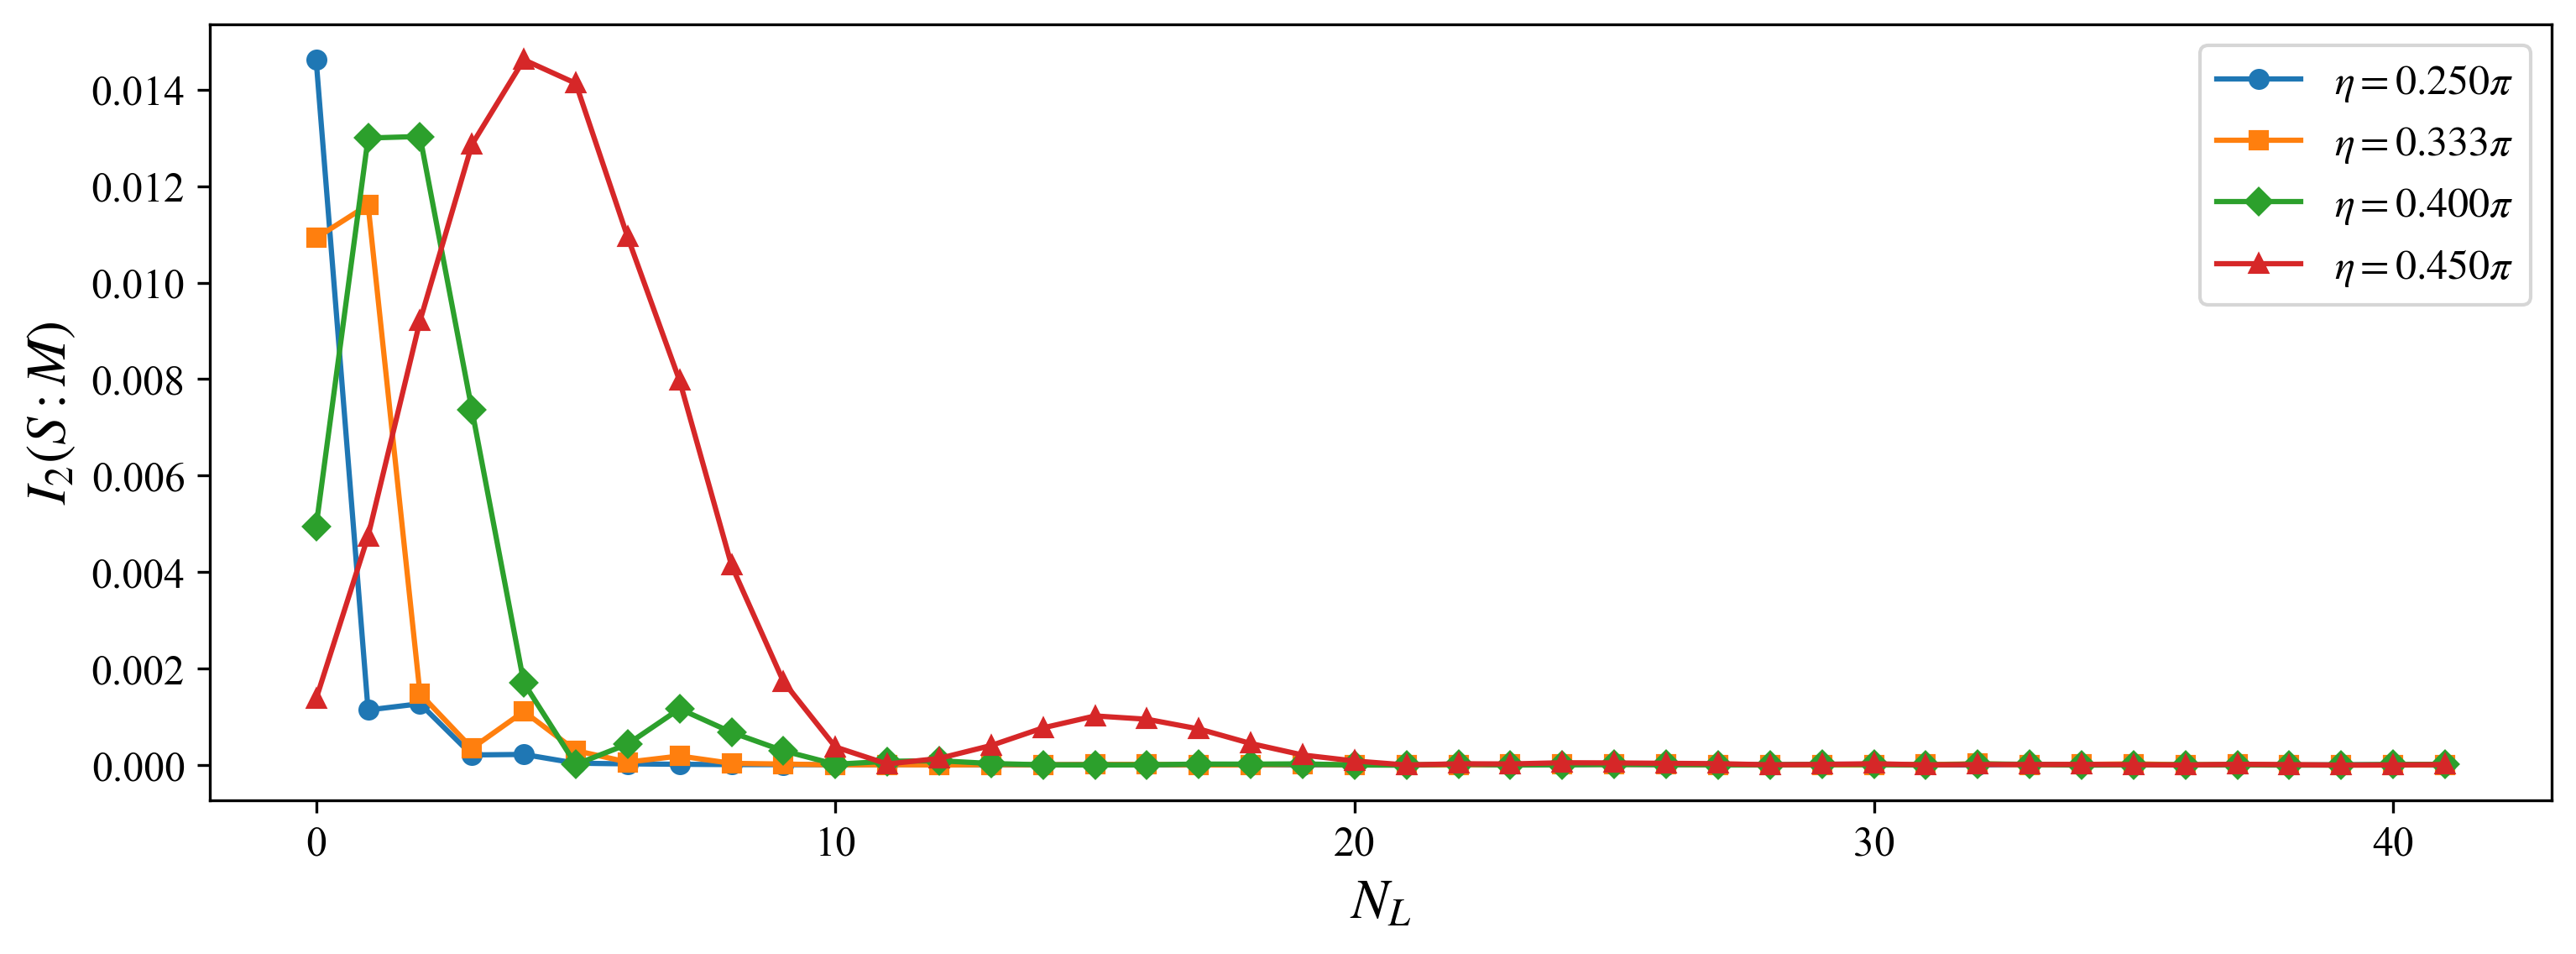

In [34]:
plt.figure(figsize=(12, 4), dpi=300)
dot = ['o', 's', 'D', '^']
for i in range(len(eta)):
    plt.plot(NL, I2_SM12[i, :], 
             label=r'$\eta={:.3f}\pi$'.format(eta[i]/np.pi),
             marker=dot[i], markersize=5)
plt.xlabel(r'$N_L$', fontsize=16)
plt.ylabel(r'$I_2(S:M)$', fontsize=16)
plt.legend()
plt.savefig('pic\BMI-s_r={}-m1_r={}.pdf'.format(s_r, m1_r),
             dpi=300, bbox_inches='tight')

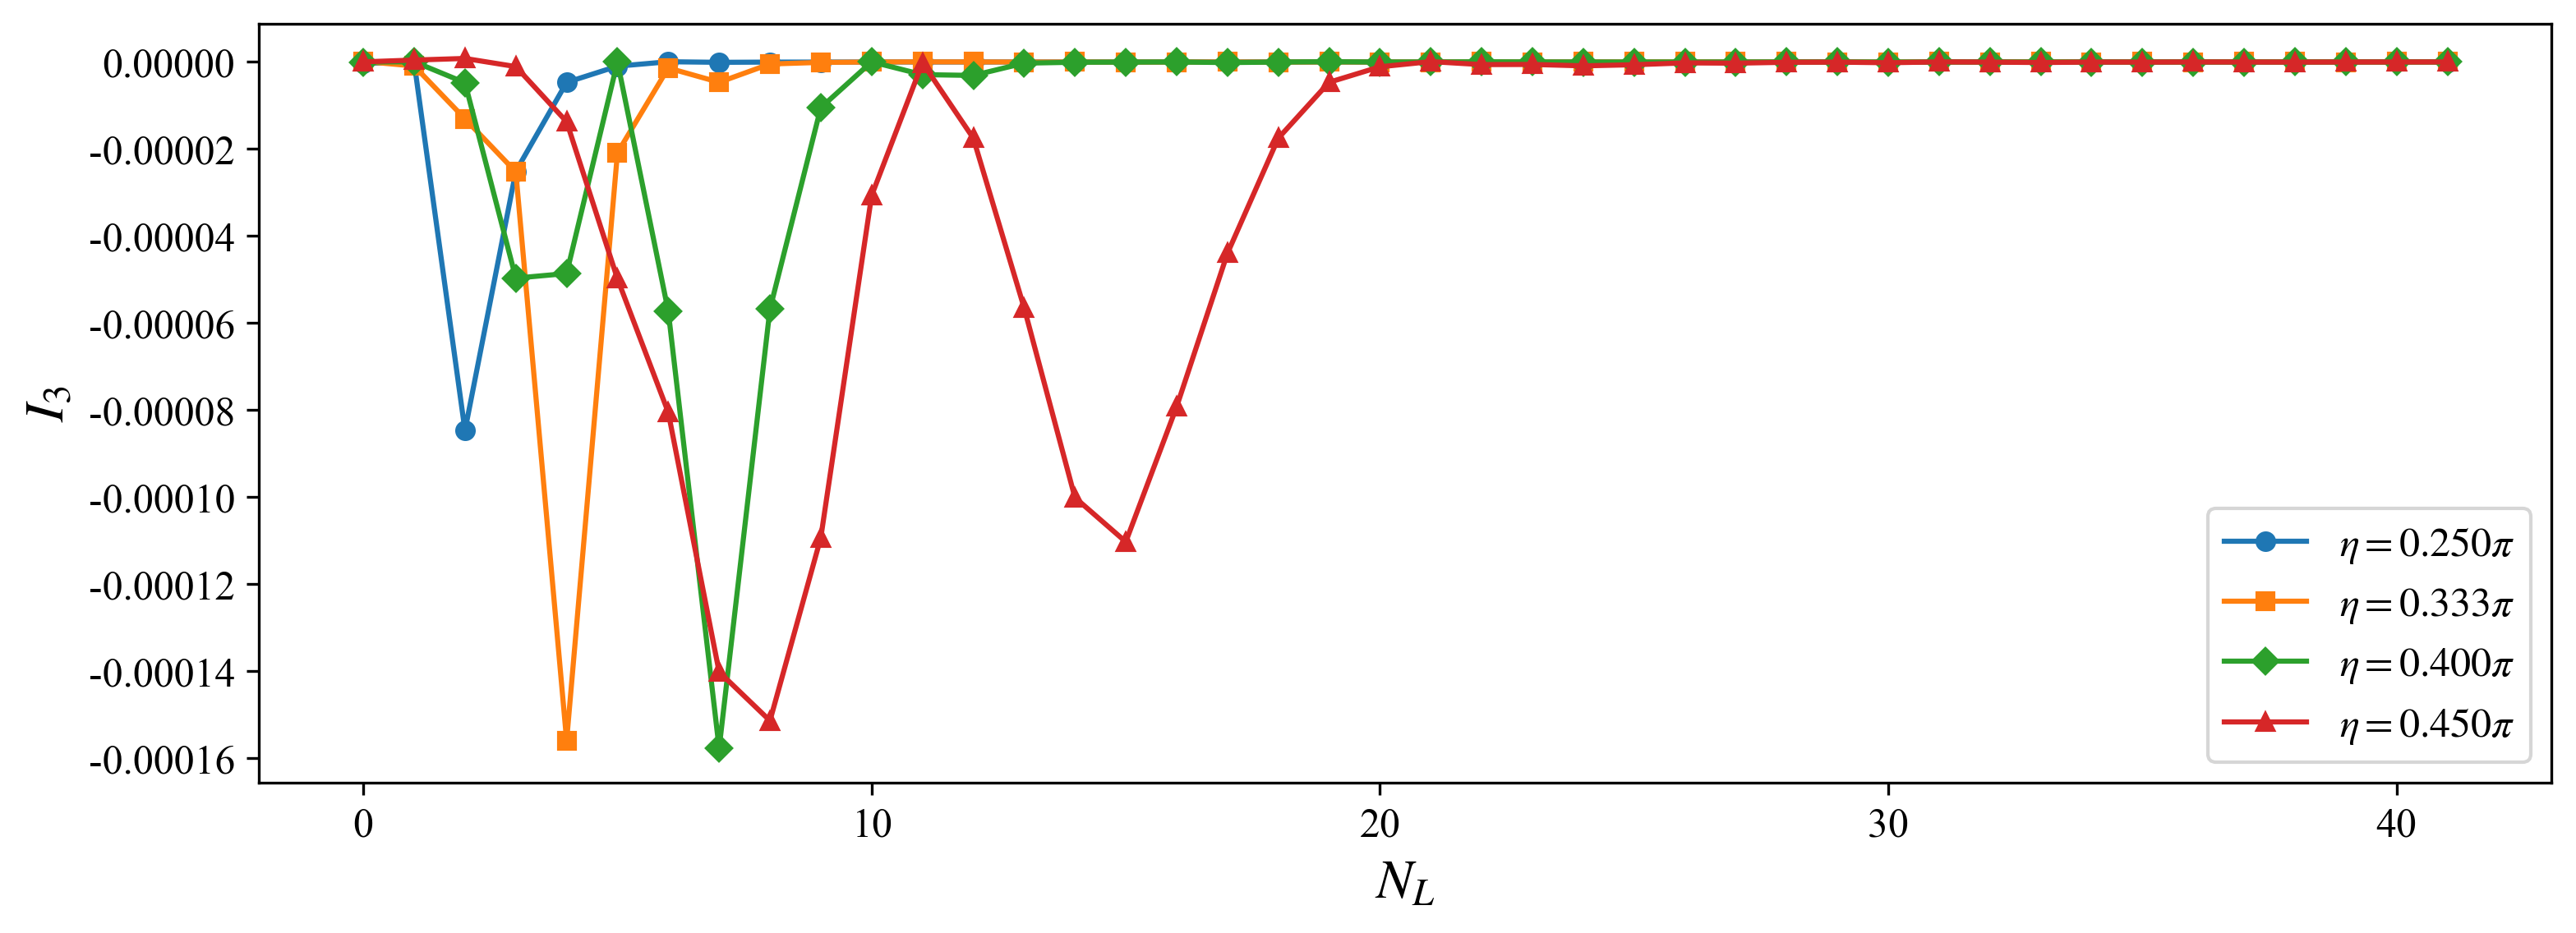

In [35]:
plt.figure(figsize=(12, 4), dpi=300)
dot = ['o', 's', 'D', '^']
for i in range(len(eta)):
    plt.plot(NL, I3[i, :], 
             label=r'$\eta={:.3f}\pi$'.format(eta[i]/np.pi), 
             marker=dot[i], markersize=5)
plt.xlabel(r'$N_L$', fontsize=16)
plt.ylabel(r'$I_3$', fontsize=16)
plt.legend()
plt.savefig('pic\TMI-s_r={}-m1_r={}.pdf'.format(s_r, m1_r), 
            dpi=300, bbox_inches='tight')